In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

In [ ]:
df = pd.read_csv('/content/penguins.csv')
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [ ]:
for col in df.select_dtypes(include=np.number).columns:
  df[col]=df[col].fillna(df[col].median())

  for col in df.select_dtypes(include='object').columns:
    df[col]=df[col].fillna(df[col].mode()[0])

In [ ]:
le_dict ={}
for col in df.select_dtypes(include='object').columns:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  le_dict[col] = le

In [ ]:
x = df.drop('sex', axis=1)
y = df['sex']

In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [ ]:
pca = PCA()
param_grid = {'n_components': list(range(1, x.shape[1]+1))}

grid_pca = GridSearchCV(pca, param_grid, cv=10)
grid_pca.fit(x_scaled)

best_n = grid_pca.best_params_['n_components']
print("Best number of components: ", best_n)

Best number of components:  1


In [ ]:
pca = PCA(n_components=best_n)
x_pca = pca.fit_transform(x_scaled)

In [ ]:
pca=PCA(n_components=best_n)
x_pca=pca.fit_transform(x_scaled)
x_pca

array([[-1.27063054],
       [-0.85787006],
       [-1.37374369],
       [-0.10711869],
       [-1.91854976],
       [-1.81176492],
       [-1.16560252],
       [-0.73193499],
       [-1.86736378],
       [-0.45639863],
       [-1.3685633 ],
       [-1.0934239 ],
       [-1.23039748],
       [-1.91487355],
       [-1.85262456],
       [-1.34575578],
       [-1.63210845],
       [-0.80641034],
       [-2.03515495],
       [-0.88634994],
       [-1.59223232],
       [-1.54029319],
       [-1.69208328],
       [-1.04958491],
       [-0.88136844],
       [-1.67933132],
       [-1.25063302],
       [-1.36898341],
       [-1.86195087],
       [-1.01104457],
       [-1.13011724],
       [-1.19619797],
       [-1.36705088],
       [-1.0094026 ],
       [-1.46907941],
       [-1.54035186],
       [-1.46746988],
       [-1.05741493],
       [-1.94755517],
       [-0.56367056],
       [-1.85607046],
       [-0.89211697],
       [-2.0757265 ],
       [-0.466541  ],
       [-1.64688673],
       [-0

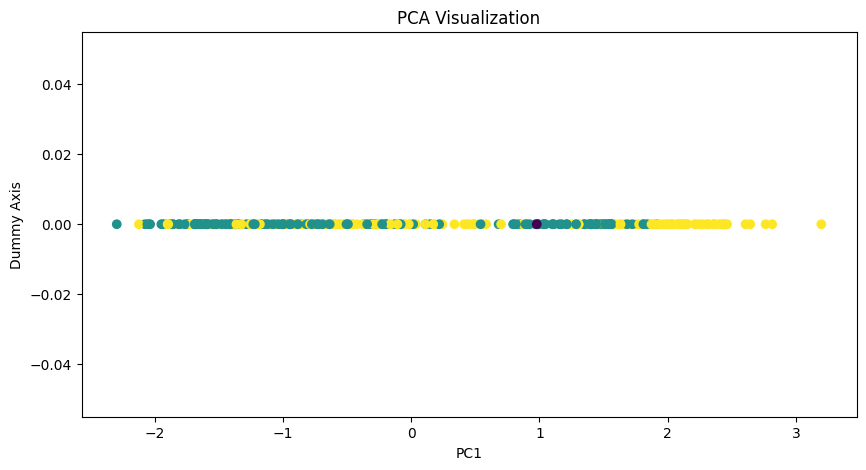

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(x_pca[:,0],np.zeros_like(x_pca[:,0]),c=y)
plt.xlabel("PC1")
plt.ylabel("Dummy Axis")
plt.title("PCA Visualization")
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.2, random_state =42)

In [ ]:
df = DecisionTreeClassifier(random_state=42)
param_grid_dt={
    'criterion':['gini','entropy'],
    'max_depth': [2,3,4,5,6],
    'min_samples_split':[2,3,5,10],
    'min_samples_leaf':[1,2,3,4,]
}
grid_dt=GridSearchCV(df,param_grid_dt,cv=10)
grid_dt.fit(x_train,y_train)
best_model = grid_dt.best_estimator_
print("best parameters:", grid_dt.best_params_)
print("best criterion:", grid_dt.best_params_['criterion'])


best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 2}
best criterion: entropy


In [ ]:
y_pred = best_model.predict(x_test)


In [ ]:
cm=confusion_matrix(y_test,y_pred)
acc=accuracy_score(y_test,y_pred)
f1=f1_score(y_test,y_pred,average='weighted')
print("Confusion Matrix:")
print(cm)
print("Accuracy:",acc)
print("F1 Score:",f1)

Confusion Matrix:
[[ 0  1  0]
 [ 0 16 14]
 [ 0  9 29]]
Accuracy: 0.6521739130434783
F1 Score: 0.6427932418270582


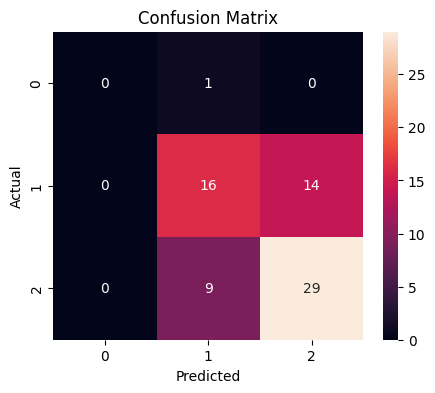

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()